In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_excel("Filtered Data with Subtypes Again.xlsx")

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()


# Loop through each metric to calculate percent change and predicted values (ignoring non-consecutive years)
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    df[pct_col] = df.groupby("ein")[m].pct_change()
    df.loc[df["year_diff"] != 1, pct_col] = None

In [17]:
median_growth = (
    df
    .groupby(["Year", "Type", "subtype"])
    [[f"{m.lower()}_pct_change" for m in metrics]]
    .median()
    .reset_index()
)

#median_growth["Year"] = median_growth["Year"] + 1

# Rename columns to indicate these are median growth values
median_growth = median_growth.rename(
    columns={
        f"{m.lower()}_pct_change": f"median_{m.lower()}_growth"
        for m in metrics
    }
)

# Merge the median growth values back into the original DataFrame
df = df.merge(
    median_growth,
    on=["Year", "Type", "subtype"],
    how="left"
)

for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)
    df[f"predicted_{m.lower()}"] = prev_actual * (1 + df[f"median_{m.lower()}_growth"])


# Use median growth to predict the next year's value for each metric
#for m in metrics:
#    df[f"predicted_{m.lower()}"] = (
#        df[m] / (1 + df[f"median_{m.lower()}_growth"])
#    )

predictions = df.copy()
predictions["Year"] = predictions["Year"] + 1

In [18]:
# Convert predicted columns to numeric and replace invalid values
import numpy as np

# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions",  "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

In [19]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

print(RE_account_by_year)


[nan, 0.0722069597069596, 0.05899705014749257, 0.046296296296296294, 0.051940099092579246, 0.04922775607820781, 0.04819976771196277, 0.04154302670623163, 0.043778194649158275, 0.0426778642262568, 0.04408998161921192, 0.04156862745098034, 0.03872418387741513, 0.04838709677419355, 0.03858356110894201, 0.034482758620689655, 0.028704893664341993, 0.028208012828384005]


C:\Users\marsh\AppData\Local\Temp\ipykernel_22396\1353895012.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


In [20]:
def relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna()&df[actual_col].notna()&(df[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

relative_error("Accounts", "predicted_accounts")

0.043778194649158275

In [21]:
print(RE_account_by_year)

[nan, 0.0722069597069596, 0.05899705014749257, 0.046296296296296294, 0.051940099092579246, 0.04922775607820781, 0.04819976771196277, 0.04154302670623163, 0.043778194649158275, 0.0426778642262568, 0.04408998161921192, 0.04156862745098034, 0.03872418387741513, 0.04838709677419355, 0.03858356110894201, 0.034482758620689655, 0.028704893664341993, 0.028208012828384005]


In [22]:
# def relative_grouped_error(actual_col, predicted_col):
#     valid_rows = group[group[predicted_col].notna()]
#     total_actual = valid_rows[actual_col].sum()
#     total_predicted = valid_rows[predicted_col].sum()
#     RE = abs((total_actual - total_predicted) / total_actual)
#     return RE

community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

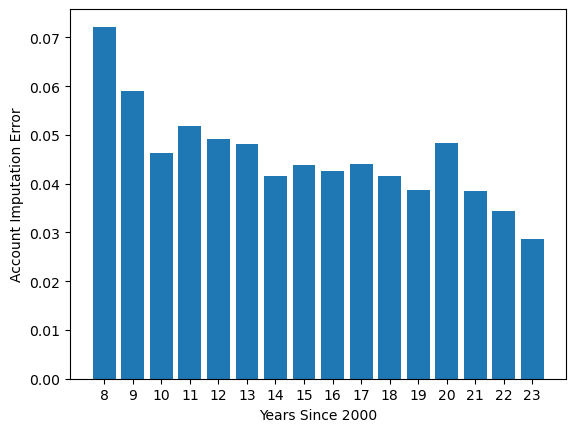

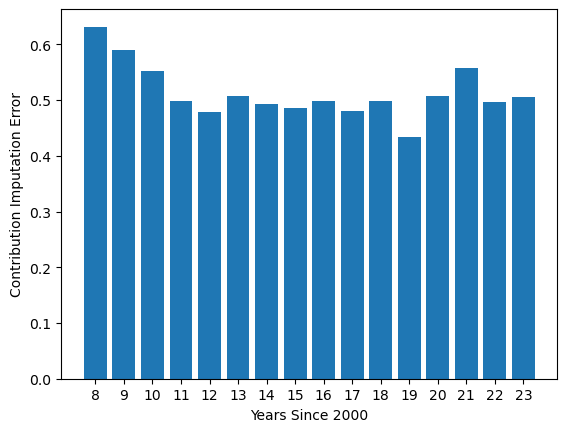

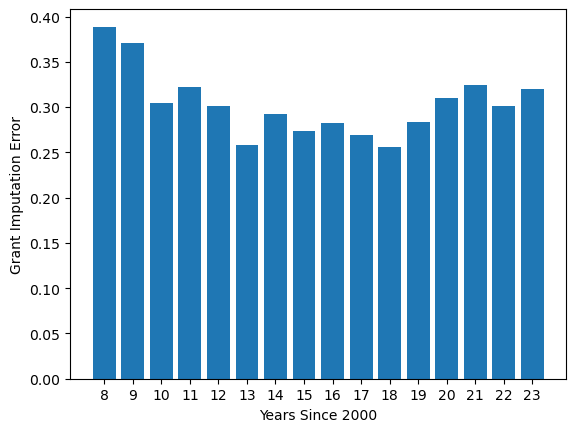

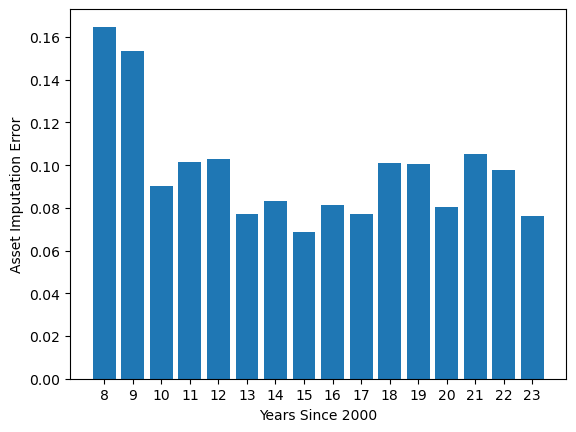

In [23]:
#2024 is discounted from these graphs because the error is exponentially greater than the rest
#2020/2021 was Covid, 2014 was when the stock market rebounded, and 2008/2009 was an economic recession
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

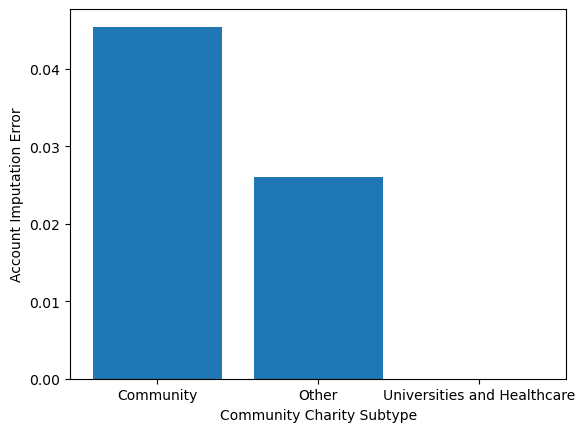

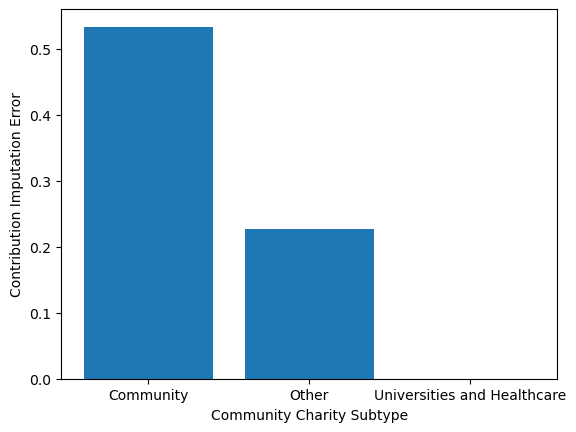

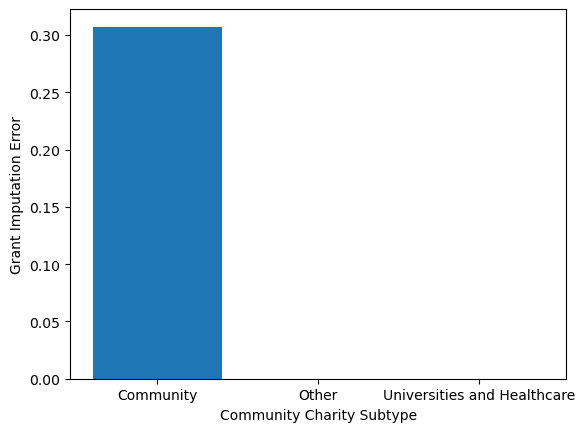

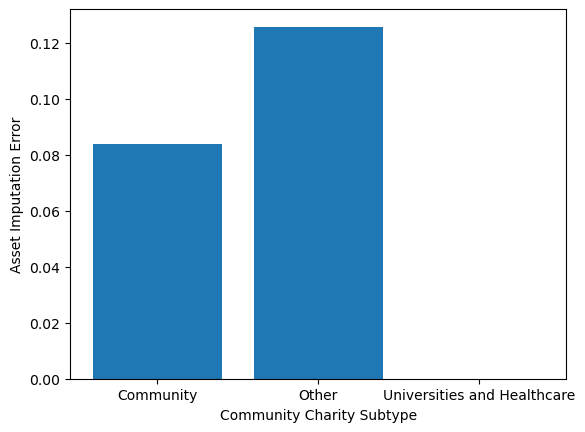

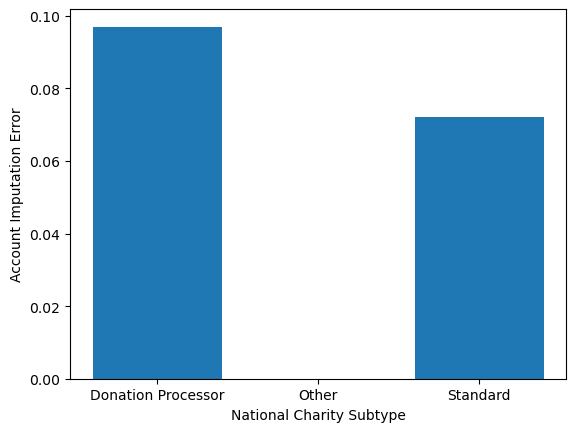

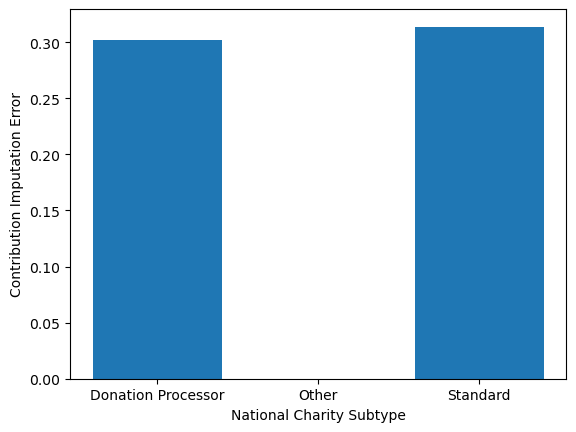

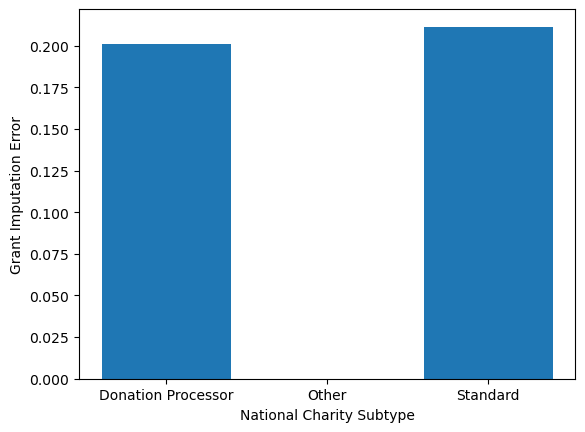

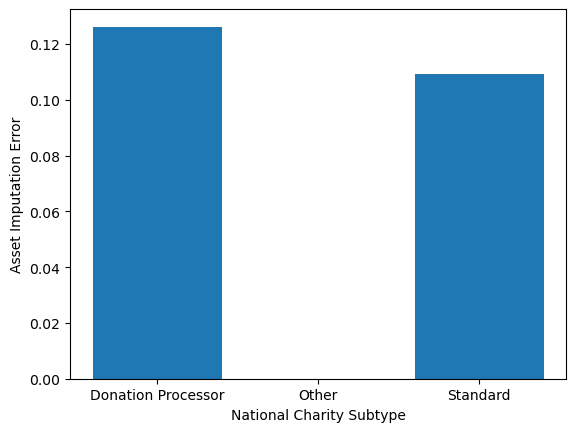

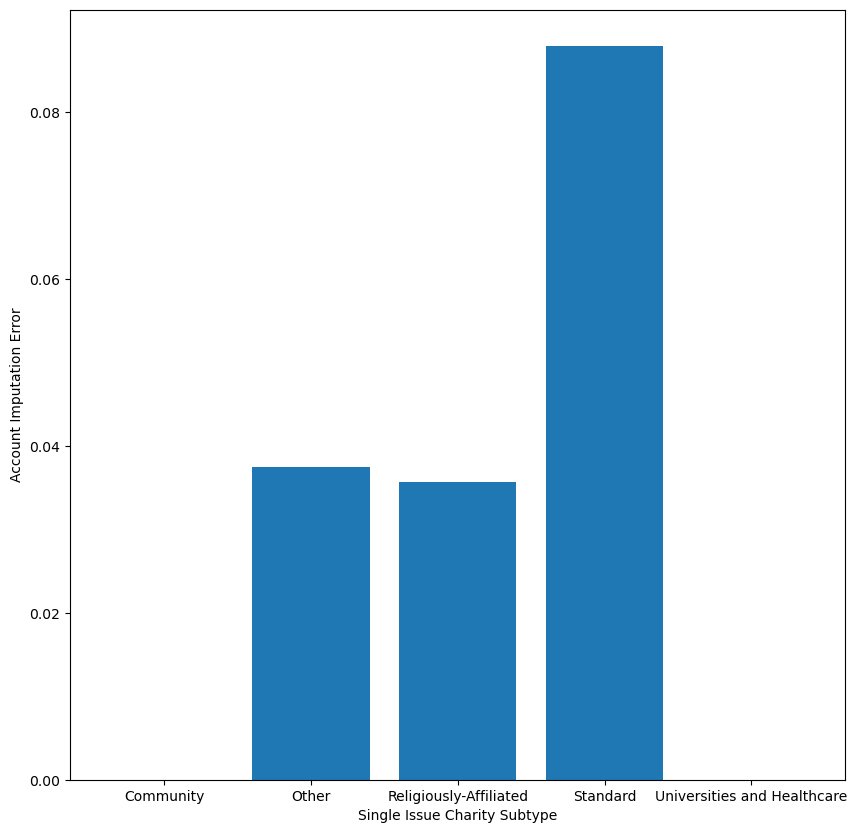

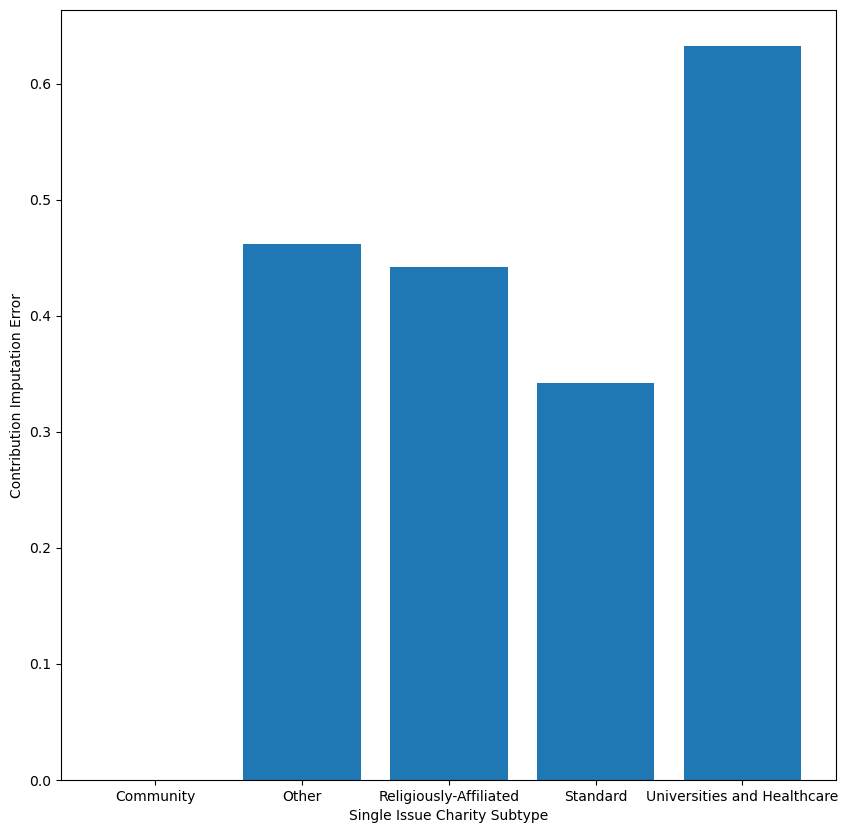

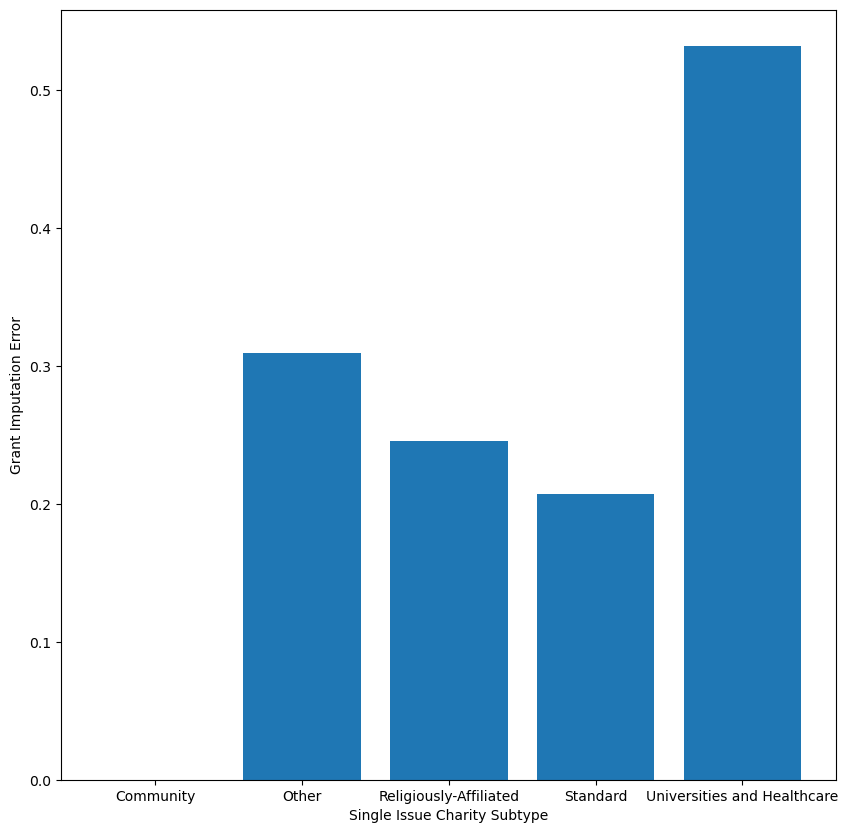

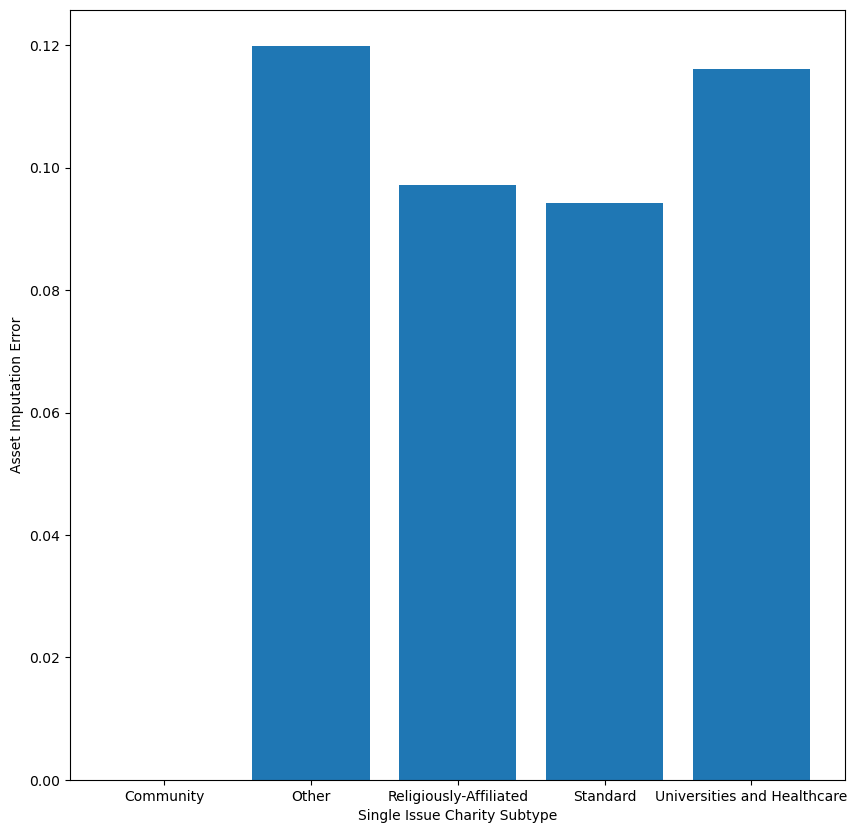

In [25]:
#Subtype Universities and Healthcare of type Community Foundation has only one charity. Thus there is no error. Same thing for Other subtype of National Charities.
plt.bar(list(cgroups.groups.keys()), community_account_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_contributions_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_grants_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_assets_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_account_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_contributions_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_grants_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_assets_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_account_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_contributions_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_grants_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_assets_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()